# Various analysis on candles

## 1. The signed-run-length + volume dataframe as a compact form of directional order flow

A 1m candle:
- Its sign is close to a coin flip — most bars have tiny bodies driven by bid-ask bounce and a handful of ticks.
- It is useful as a trigger layer once 5m defines the setup: 5m for regime and exhaustion detection, 1m for entry timing after the setup fires. That's the multi-timeframe confluence from before.

A 5M candle:
- Each bar aggregates ~5× more trades, so direction reflects who won the period, not tick noise. Doji share drops a lot.
- Volume per candle is a much cleaner estimate of conviction (5× sample size → smaller variance).
- Climaxes and exhaustion typically play out over 3–5 minutes — on 1m they get split across bars and diluted; on 5m they land as a single tall red/green bar with outsized volume, which is exactly the pattern you want to detect.
- Fee/spread drag becomes bearable. At 1m, taker fees alone often eat the expectancy.

In [10]:
from entry_exit_points.fetcher import BybitFetcher

In [11]:
SYMBOL   = "BTCUSDT"
INTERVAL = "5"

In [12]:
# Fetch data
fetcher = BybitFetcher()
df = fetcher.fetch_klines(
    symbol=SYMBOL,
    interval=INTERVAL,
    start_time="2026-04-20",
    #end_time="2026-04-01",    # optional; defaults to now
)
fetcher.close()

In [13]:
df.head()

,open,high,low,close,volume,turnover
timestamp,,,,,,
2026-04-20 00:00:00+00:00,73765.8,74191.5,73653.6,74039.0,962.703,7.114876e+07
2026-04-20 00:05:00+00:00,74039.0,74109.3,73854.9,74031.0,715.231,5.293806e+07
2026-04-20 00:10:00+00:00,74031.0,74109.2,74003.7,74008.0,144.975,1.073504e+07
2026-04-20 00:15:00+00:00,74008.0,74162.8,74007.7,74100.1,336.296,2.492894e+07
2026-04-20 00:20:00+00:00,74100.1,74218.5,74077.3,74212.4,334.286,2.479077e+07


The algorithm classifies each candle as buy/sell/doji via sign(close-open), \
then walks the series producing a signed run length (positive=buy streak, negative=sell streak, reset on direction change). \
Result is stored in the consecutive Series and plotted as a green/red bar chart.

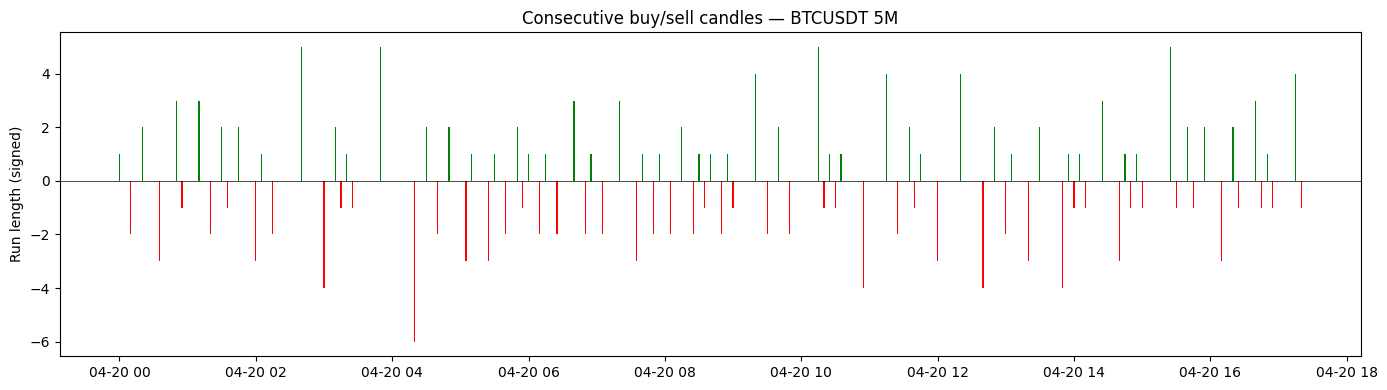

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Direction per candle: +1 buy, -1 sell, 0 doji
direction = np.sign(df['close'] - df['open']).astype(int)

# Collapse consecutive same-direction candles into one signed streak length.
# e.g. green, red, green, green, green, red -> [1, -1, 3, -1]. Dojis are skipped.
# Each streak is indexed by the timestamp of its last candle.
dirs = direction.to_numpy()
idx = df.index
lengths, timestamps = [], []
start = 0
for i in range(1, len(dirs) + 1):
    if i == len(dirs) or dirs[i] != dirs[start]:
        if dirs[start] != 0:
            lengths.append(int(dirs[start]) * (i - start))
            timestamps.append(idx[i - 1])
        start = i

consecutive = pd.Series(lengths, index=pd.DatetimeIndex(timestamps), name="consecutive_candles")

fig, ax = plt.subplots(figsize=(14, 4))
colors = np.where(consecutive >= 0, 'green', 'red')
ax.bar(consecutive.index, consecutive.values, color=colors, width=1/1440)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title(f"Consecutive buy/sell candles — {SYMBOL} {INTERVAL}M")
ax.set_ylabel("Run length (signed)")
plt.tight_layout()
plt.show()

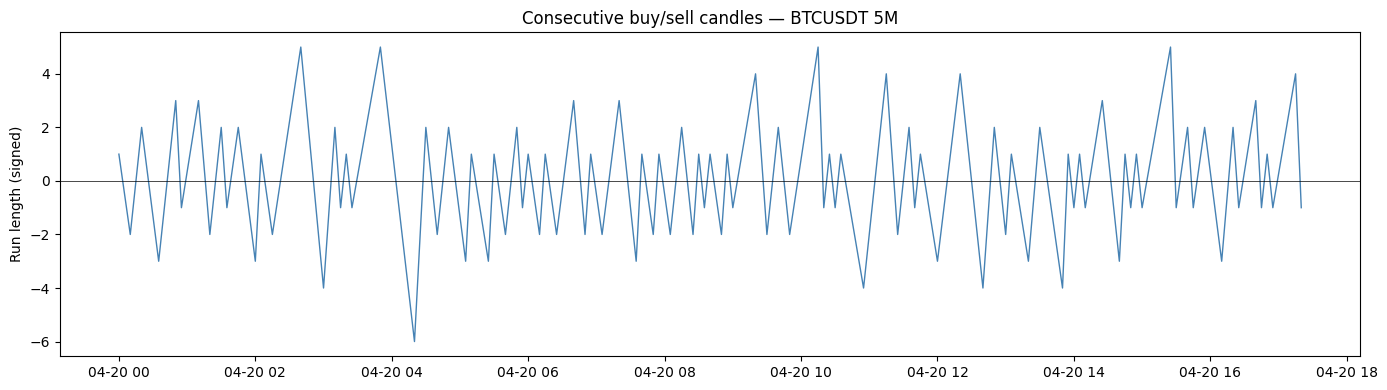

In [15]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(consecutive.index, consecutive.values, color='steelblue', linewidth=1)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title(f"Consecutive buy/sell candles — {SYMBOL} {INTERVAL}M")
ax.set_ylabel("Run length (signed)")
plt.tight_layout()
plt.show()

In [ ]:
consecutive.head(20)

In [16]:
# dataframe with the number of consecutive candles and the corresponding volume for each streak
# Per-streak dataframe: signed run length + total volume over the streak.
# Each row is one streak: consecutive_candles is signed (positive = buy run, negative = sell run), 
# volume sums the candle volumes across that run, 
# indexed by the last candle's timestamp.
vols = df['volume'].to_numpy()
rows = []
start = 0
for i in range(1, len(dirs) + 1):
    if i == len(dirs) or dirs[i] != dirs[start]:
        if dirs[start] != 0:
            rows.append({
                'end_time': idx[i - 1],
                'consecutive_candles': int(dirs[start]) * (i - start),
                'volume': float(vols[start:i].sum()),
            })
        start = i

streaks = pd.DataFrame(rows).set_index('end_time')
streaks.head(20)

,consecutive_candles,volume
end_time,,
2026-04-20 00:00:00+00:00,1,962.703
2026-04-20 00:10:00+00:00,-2,860.206
2026-04-20 00:20:00+00:00,2,670.582
2026-04-20 00:35:00+00:00,-3,885.355
2026-04-20 00:50:00+00:00,3,357.730
2026-04-20 00:55:00+00:00,-1,150.564
2026-04-20 01:10:00+00:00,3,527.405
2026-04-20 01:20:00+00:00,-2,291.015
2026-04-20 01:30:00+00:00,2,644.805


In [17]:
# Frequency of each streak length sorted by length
streaks['consecutive_candles'].value_counts().sort_index()

consecutive_candles
-6     1
-4     4
-3     9
-2    17
-1    20
 1    22
 2    15
 3     6
 4     4
 5     4
Name: count, dtype: int64

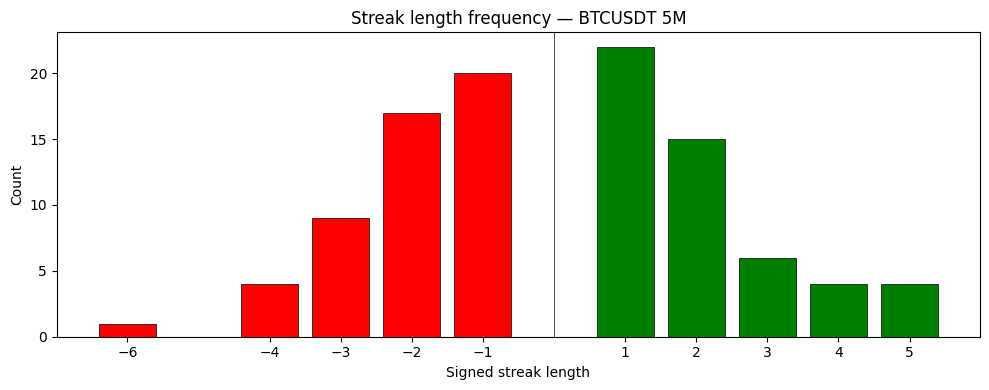

In [18]:
# Green bars = buy streaks, red = sell, bar height = how many times that length occurred.
counts = streaks['consecutive_candles'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
colors = np.where(counts.index > 0, 'green', 'red')
ax.bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel("Signed streak length")
ax.set_ylabel("Count")
ax.set_title(f"Streak length frequency — {SYMBOL} {INTERVAL}M")
ax.set_xticks(counts.index)
plt.tight_layout()
plt.show()

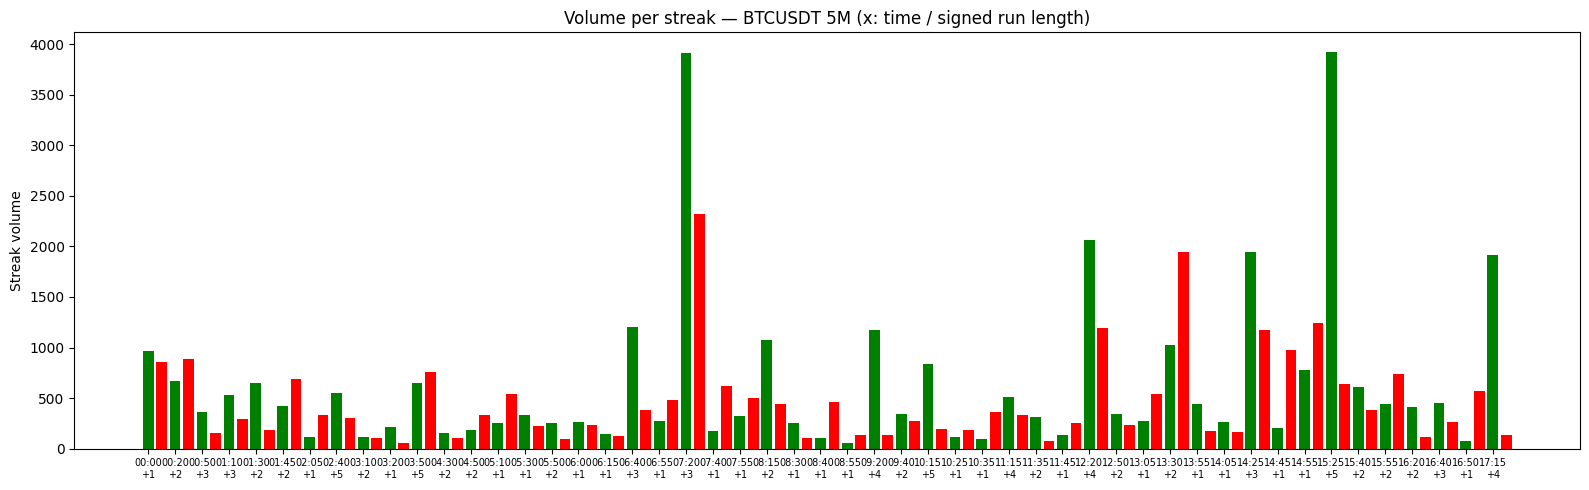

In [ ]:
# Each bar = one streak, height = total volume, green/red = buy/sell
# x-tick shows HH:MM above the signed run length
# drop the step thinning if you want every label shown
fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(streaks))
colors = np.where(streaks['consecutive_candles'] > 0, 'green', 'red')
ax.bar(x, streaks['volume'].values, color=colors)

labels = [f"{ts.strftime('%H:%M')}\n{n:+d}" for ts, n in
          zip(streaks.index, streaks['consecutive_candles'])]
step = max(1, len(streaks) // 40)
ax.set_xticks(x[::step])
ax.set_xticklabels(labels[::step], rotation=0, fontsize=7)
ax.set_ylabel("Streak volume")
ax.set_title(f"Volume per streak — {SYMBOL} {INTERVAL}M (x: time / signed run length)")
plt.tight_layout()
plt.show()

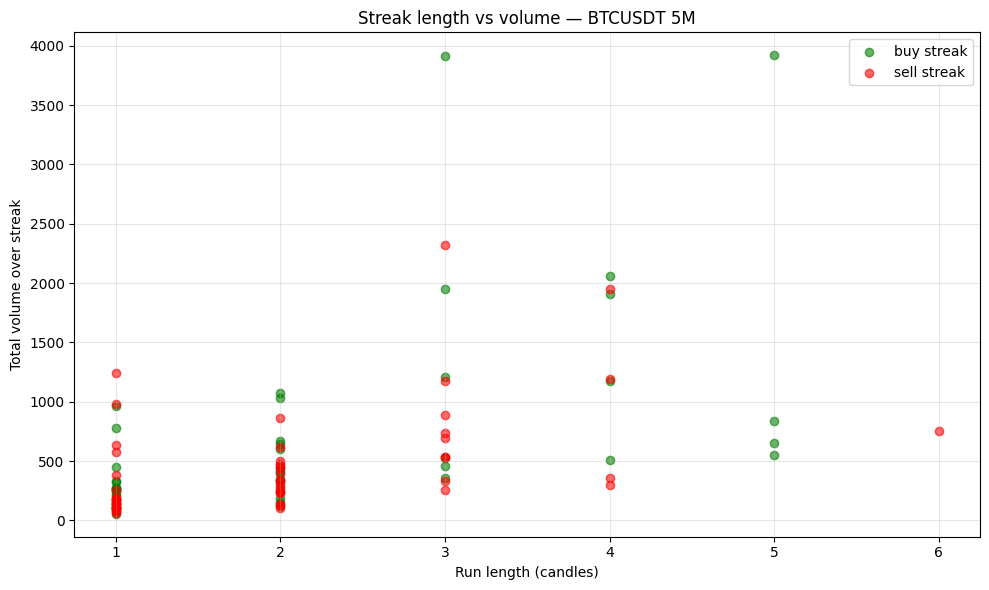

In [20]:
# Scatter of absolute run length vs total streak volume, split by direction. 
# Swap ax.set_yscale('log') in if the volume spread is too wide to read
fig, ax = plt.subplots(figsize=(10, 6))
buy = streaks[streaks['consecutive_candles'] > 0]
sell = streaks[streaks['consecutive_candles'] < 0]
ax.scatter(buy['consecutive_candles'].abs(), buy['volume'], color='green', alpha=0.6, label='buy streak')
ax.scatter(sell['consecutive_candles'].abs(), sell['volume'], color='red', alpha=0.6, label='sell streak')
ax.set_xlabel("Run length (candles)")
ax.set_ylabel("Total volume over streak")
ax.set_title(f"Streak length vs volume — {SYMBOL} {INTERVAL}M")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()